In [115]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns

In [116]:
# Макроэкономические показатели США
# Загрузка датасета
data = pd.read_csv('/content/macro_monthly.csv')
data.head()

,Year,Month,Industrial_Production,Manufacturers_New_Orders: Durable Goods,Consumer_Price Index,Unemployment_Rate,Retail_Sales,Producer_Price_Index,Personal_Consumption_Expenditures,National_Home_Price_Index,All_Employees(Total_Nonfarm),Labor_Force_Participation_Rate,Federal_Funds_Effective_Rate,Building_Permits,Money_Supply_(M2),Personal_Income,Trade_Balance,Consumer_Sentiment,Consumer_Confidence
0,1993,1,0.39,-3.52,0.35,-1.35,1.16,0.34,0.24,0.14,0.26,-0.15,-0.51,0.09,-0.16,-2.51,30.91,-1.87,-1.87
1,1993,2,0.48,5.93,0.21,-2.74,-0.78,0.34,0.15,0.07,0.23,0.00,0.59,-2.46,-0.13,0.61,7.10,-3.02,-3.02
2,1993,3,-0.10,-1.62,0.14,-1.41,-0.83,0.25,0.20,0.04,-0.04,0.00,0.40,-8.01,-0.08,-0.05,-88.46,-0.81,-0.81
3,1993,4,0.28,0.50,0.35,1.43,2.58,0.51,0.27,0.09,0.27,-0.15,-0.34,4.55,-0.01,1.02,4.90,-0.35,-0.35
4,1993,5,-0.37,-0.68,0.28,0.00,0.95,0.34,0.31,0.13,0.25,0.45,-0.30,0.72,0.75,0.29,32.21,-6.19,-6.19


In [117]:
# информация о загруженном датасете - общая сводка
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Year                                     384 non-null    int64  
 1   Month                                    384 non-null    int64  
 2   Industrial_Production                    384 non-null    float64
 3   Manufacturers_New_Orders: Durable Goods  384 non-null    float64
 4   Consumer_Price Index                     384 non-null    float64
 5   Unemployment_Rate                        384 non-null    float64
 6   Retail_Sales                             384 non-null    float64
 7   Producer_Price_Index                     384 non-null    float64
 8   Personal_Consumption_Expenditures        384 non-null    float64
 9   National_Home_Price_Index                384 non-null    float64
 10  All_Employees(Total_Nonfarm)             384 non-n

In [118]:
data.describe()

,Year,Month,Industrial_Production,Manufacturers_New_Orders: Durable Goods,Consumer_Price Index,Unemployment_Rate,Retail_Sales,Producer_Price_Index,Personal_Consumption_Expenditures,National_Home_Price_Index,All_Employees(Total_Nonfarm),Labor_Force_Participation_Rate,Federal_Funds_Effective_Rate,Building_Permits,Money_Supply_(M2),Personal_Income,Trade_Balance,Consumer_Sentiment,Consumer_Confidence
count,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000
mean,2008.500000,6.500000,0.128464,0.302031,0.209583,0.205807,0.390937,0.206354,0.173437,0.380312,0.099974,-0.015000,0.003672,0.186016,0.480703,0.401172,-1.352318,0.075937,0.075937
std,9.245138,3.456556,1.045151,4.383600,0.276460,12.562540,1.767972,1.102193,0.201588,0.561040,0.750472,0.303633,0.357229,4.995053,0.564328,1.663401,11.458615,5.074700,5.074700
min,1993.000000,1.000000,-13.240000,-21.280000,-1.770000,-17.650000,-14.520000,-5.330000,-1.180000,-1.620000,-13.570000,-3.990000,-1.720000,-21.950000,-1.460000,-12.950000,-88.460000,-19.420000,-19.420000
25%,2000.750000,3.750000,-0.200000,-1.737500,0.070000,-2.220000,-0.150000,-0.260000,0.070000,0.170000,0.060000,-0.150000,-0.052500,-2.745000,0.230000,0.217500,-6.165000,-2.625000,-2.625000
50%,2008.500000,6.500000,0.190000,0.385000,0.210000,0.000000,0.390000,0.225000,0.170000,0.390000,0.140000,0.000000,0.000000,0.090000,0.430000,0.400000,-0.920000,0.000000,0.000000
75%,2016.250000,9.250000,0.552500,2.550000,0.330000,1.790000,0.910000,0.755000,0.282500,0.660000,0.210000,0.150000,0.090000,3.087500,0.630000,0.542500,4.240000,3.007500,3.007500
max,2024.000000,12.000000,6.580000,25.880000,1.380000,236.360000,18.780000,3.210000,0.970000,1.880000,3.480000,1.160000,2.490000,18.590000,6.330000,20.810000,34.920000,13.700000,13.700000


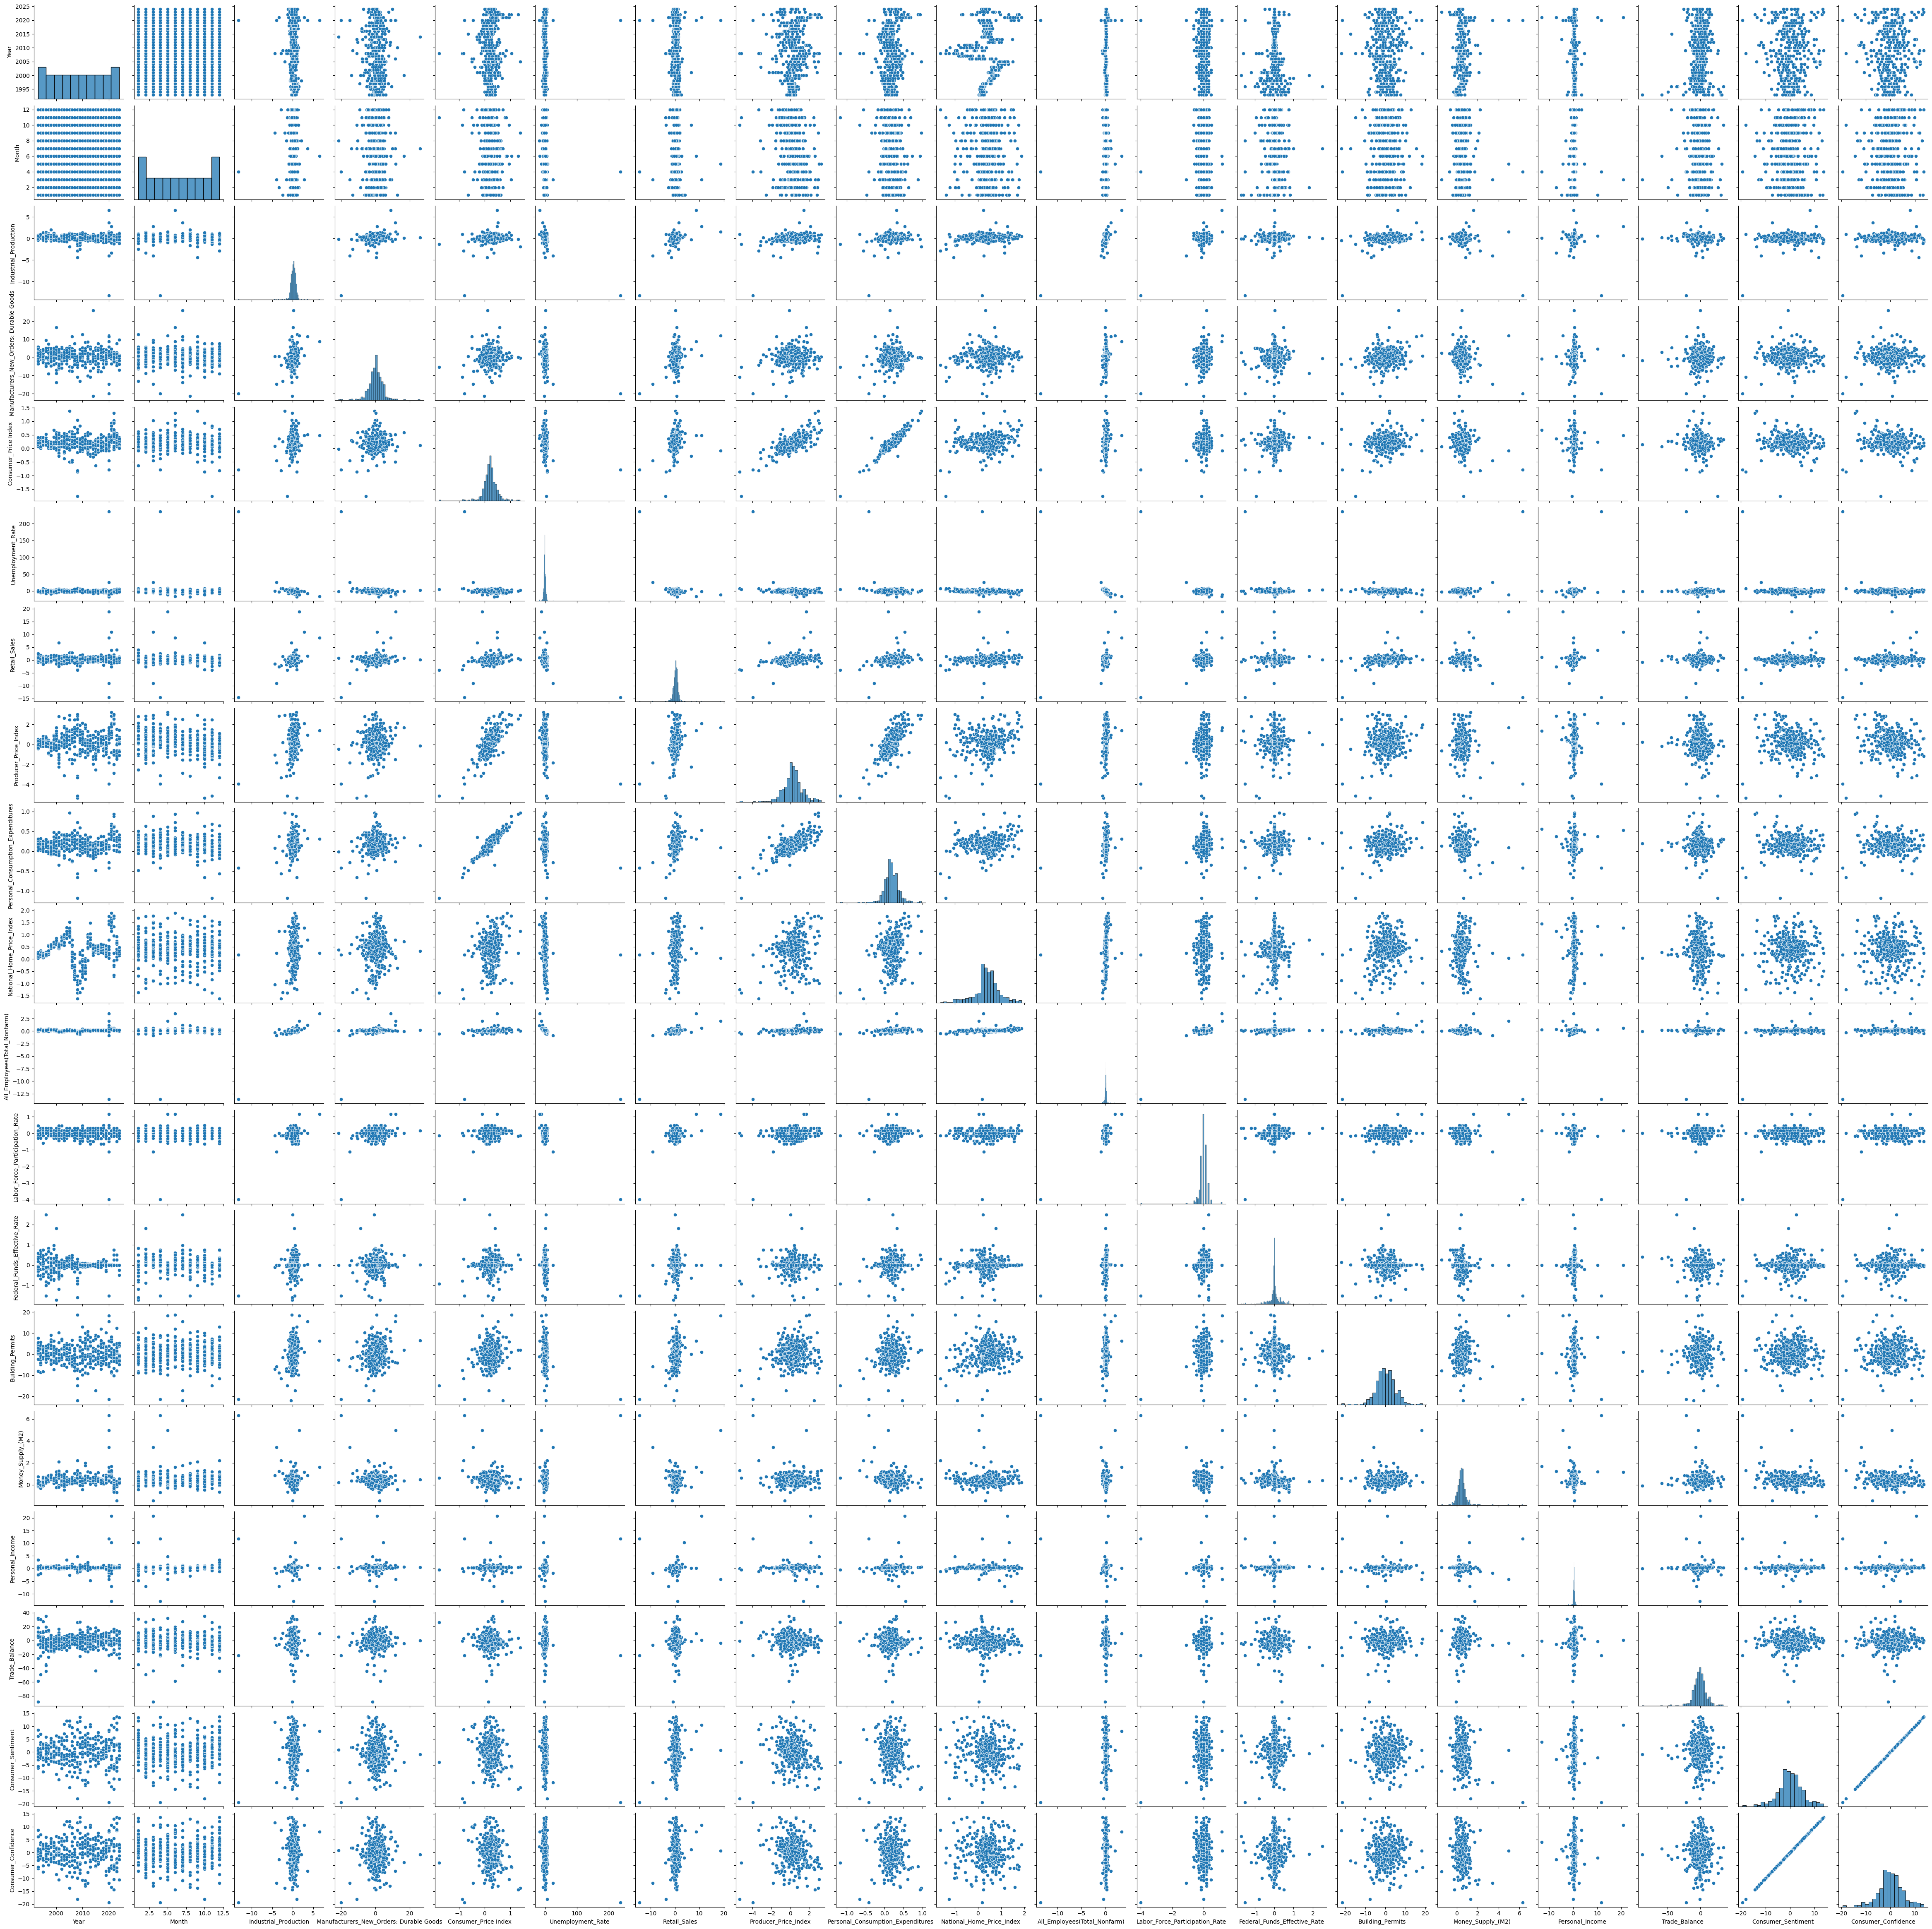

In [119]:
# Парные представления данных
sns.pairplot(data)
plt.show()

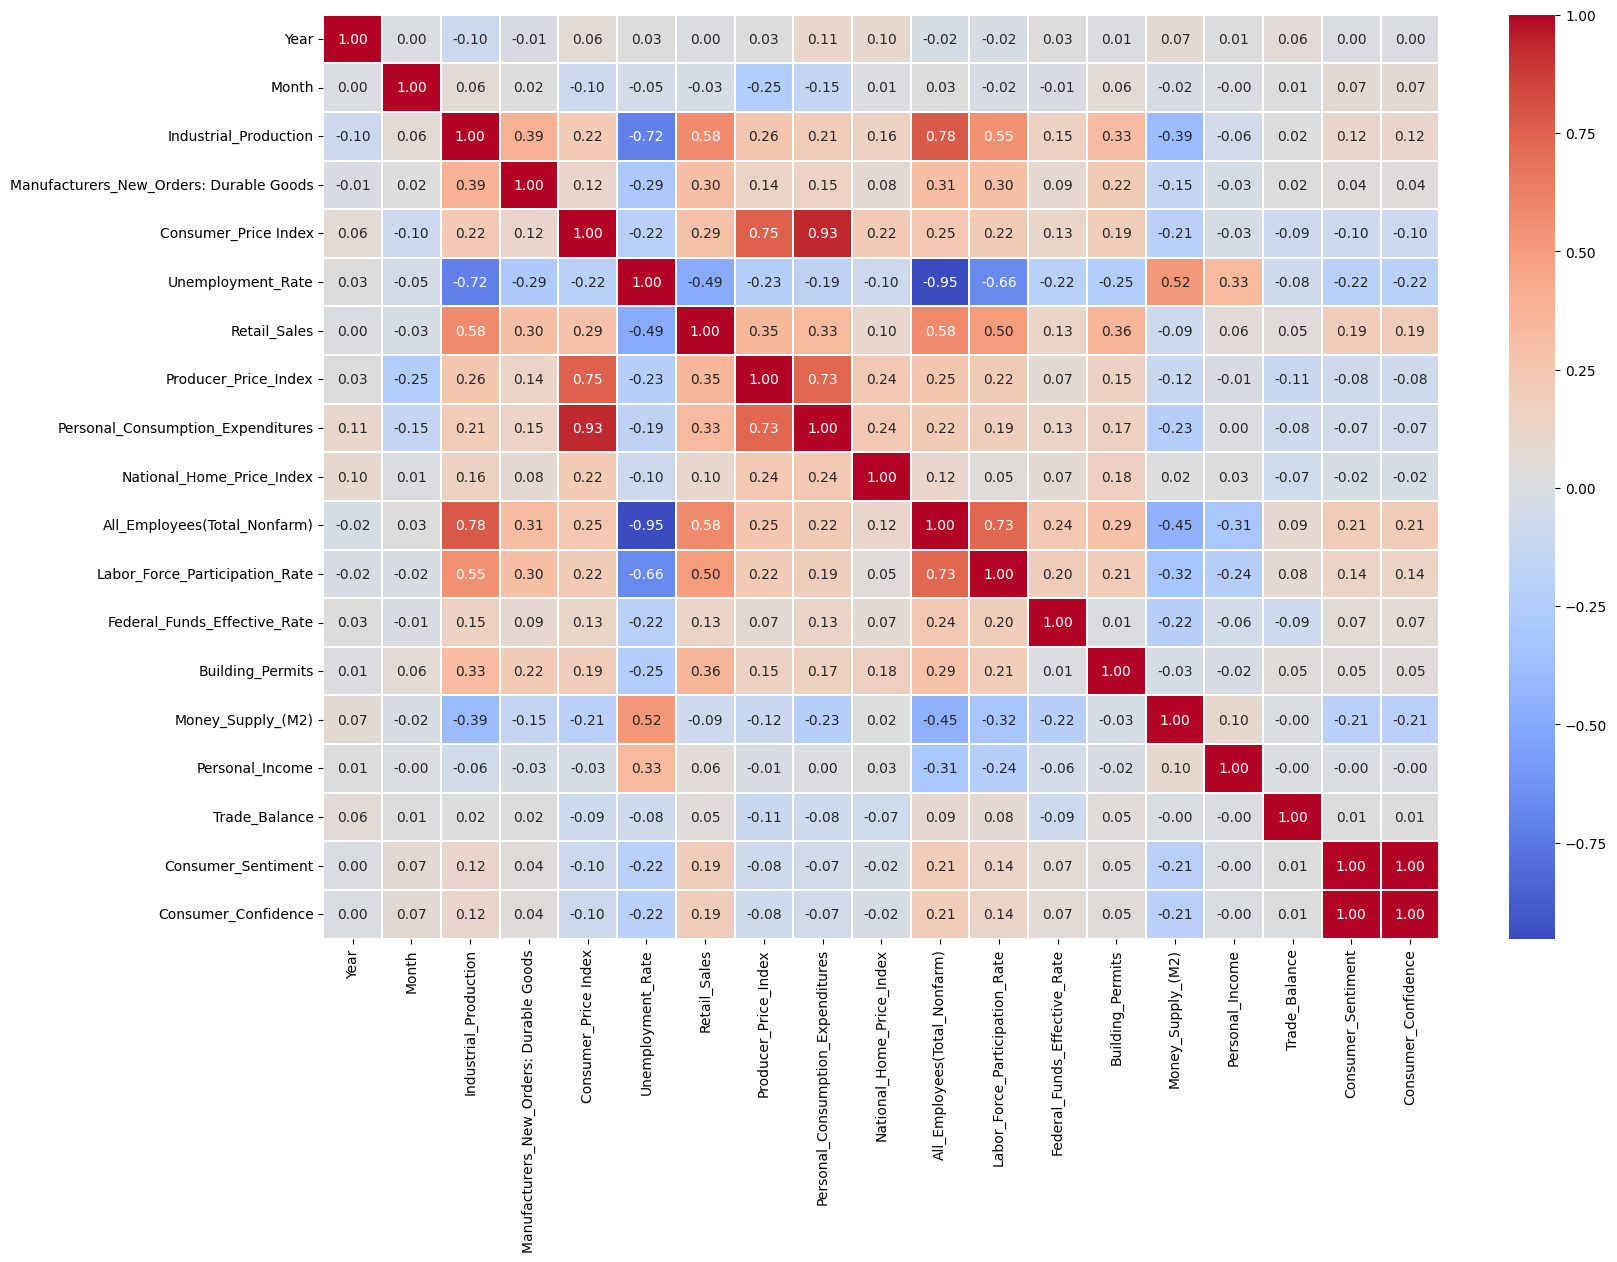

In [120]:
# Корреляция параметров
plt.figure(figsize=(18,12))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.01)
plt.show()

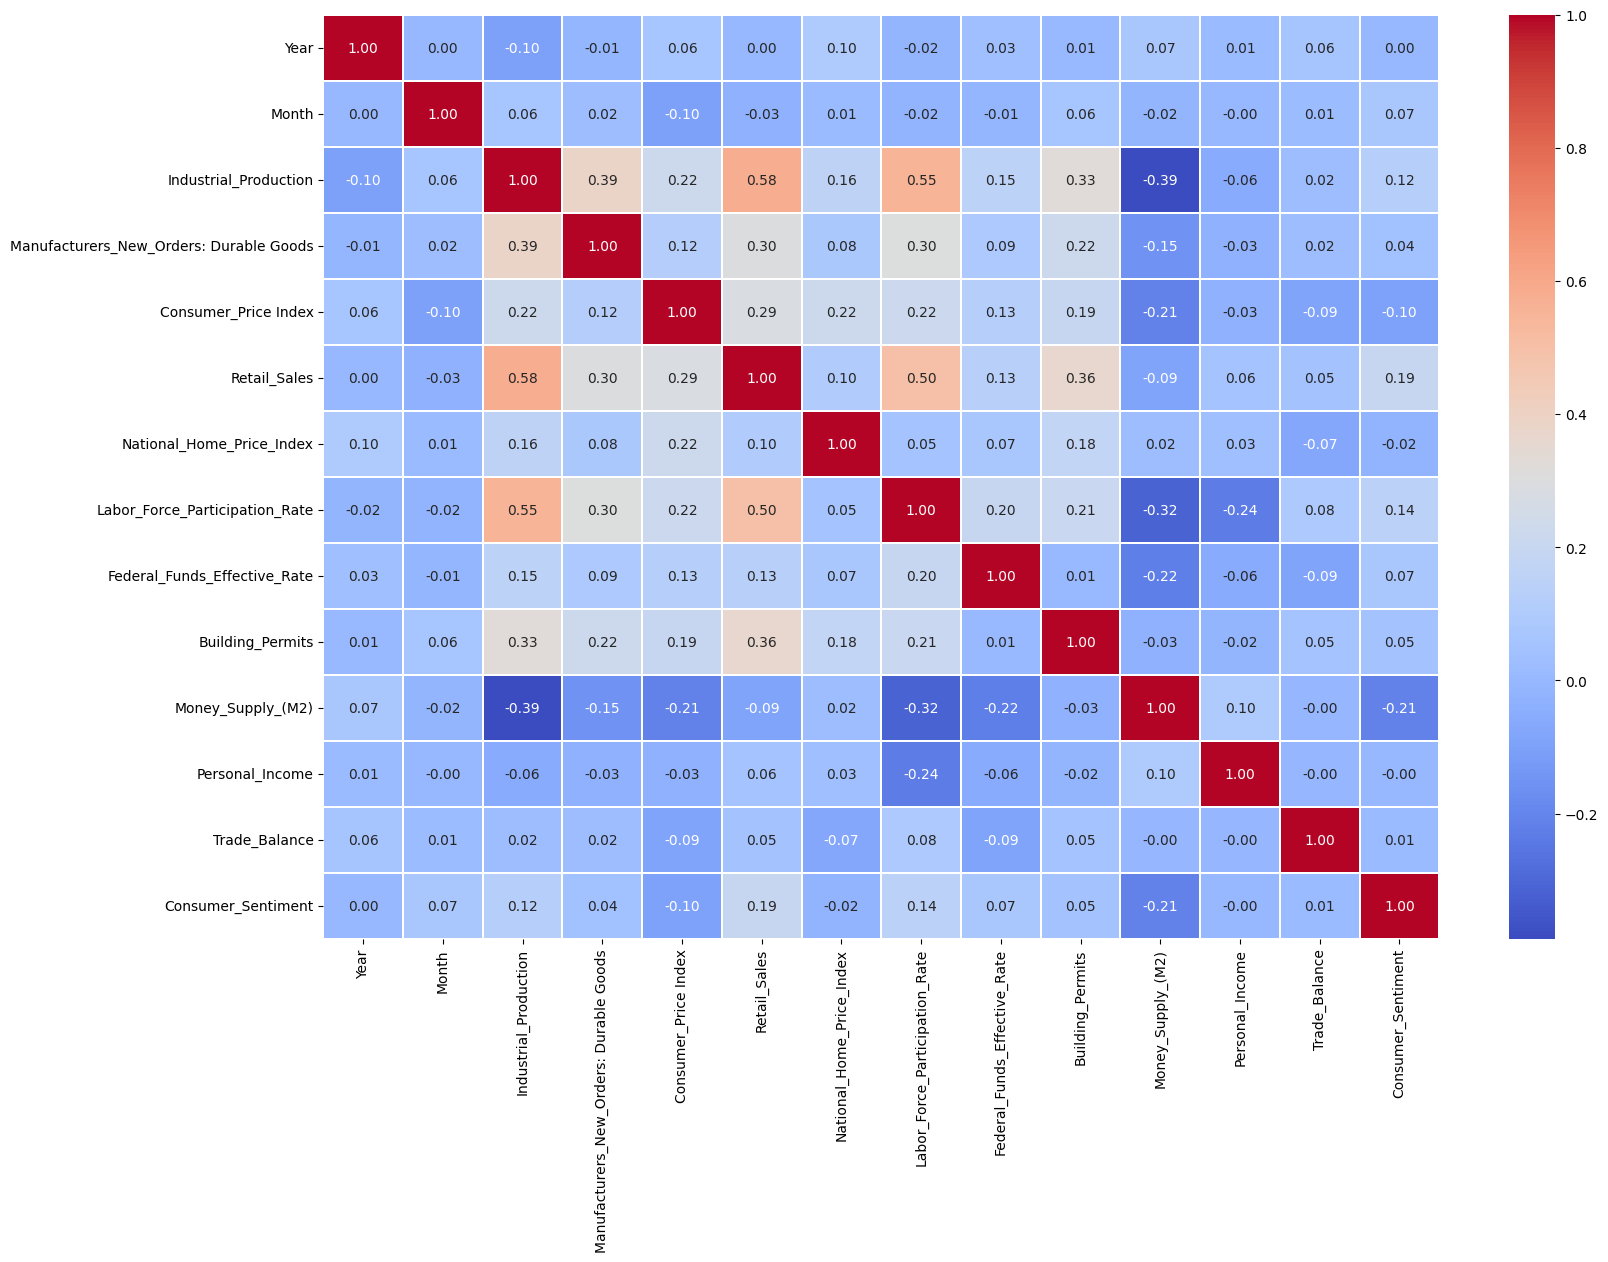

In [121]:
# Исключение параметров с высокой корреляцией
# Consumer_Confidence - дублирующий параметр
# All_Employees(Total_Nonfarm) - высокий показатель корреляции с 3 параметрами
# Unemployment_Rate - высокий показатель корреляции с 3 параметрами
# Personal_Consumption_Expenditures - используется для вычисления Consumer_Price_Index
# Producer_Price_Index - прямо влияет на потребительские цены
data = data.drop(['Consumer_Confidence', 'All_Employees(Total_Nonfarm)', 'Personal_Consumption_Expenditures', 'Producer_Price_Index', 'Unemployment_Rate'], axis=1)

# Корреляция параметров
plt.figure(figsize=(18,12))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.01)
plt.show()

In [122]:
# Преобразование даты
data['Date'] = pd.Series(dtype='str')

i = 0
while i < 384:
    if data['Month'].iloc[i] < 10:
        data.loc[i, 'Date'] = (str(data['Year'].iloc[i])+'-0'+str(data['Month'].iloc[i]))
    else:
        data.loc[i, 'Date'] = (str(data['Year'].iloc[i])+'-'+str(data['Month'].iloc[i]))
    i += 1

data = data.drop(['Year', 'Month'], axis=1)

In [123]:
# Разделение признаков
X = data.drop('Consumer_Price Index', axis=1)
y = data['Consumer_Price Index']

# Разделение данных
X_train = X[0:276]
y_train = y[0:276]
X_test = X[276:384]
y_test = y[276:384]

print(f'X_train-{X_train.shape}\nX_test-{X_test.shape}\ny_train-{y_train.shape}\ny_test-{y_test.shape}')

X_train-(276, 12)
X_test-(108, 12)
y_train-(276,)
y_test-(108,)


In [125]:
# Приведение к числовому формату
i = 1
while i < 277:
    X_train.loc[i-1, 'Date'] = i
    i += 1

i = 277
while i < 385:
    X_test.loc[i-1, 'Date'] = i
    i += 1

# нормализация данных
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [126]:
# Инициализация моделей регрессоров
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Neighbors': KNeighborsRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

In [127]:
# Оптимизация гиперпараметров: подбираем лучшие параметры для каждой модели
params = {
    'Decision Tree': {'max_depth': [2, 3, 5]},
    'Random Forest': {'n_estimators': [50, 100]},
    'K-Neighbors': {'n_neighbors': [3, 5, 7]},
    'Gradient Boosting': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}
}

Обучение и оценка

In [128]:
# Список для хранения резуьтата
results = []
for name, model in models.items():
    if name in params:
        # Оптимизация гиперпараметров: перебор всех возможных комбинаций параметров по сетке
        gs = GridSearchCV(model, params[name], cv=3, scoring='r2')
        gs.fit(X_train_scaled if name == 'K-Neighbors' else X_train, y_train)
        best_model = gs.best_estimator_
    else:
        best_model = model.fit(X_train, y_train)

    if name == 'K-Neighbors':
        y_pred = best_model.predict(X_test_scaled)
    else:
        y_pred = best_model.predict(X_test)

    print('\n', name)
    print('MAE: ', mean_absolute_error(y_test, y_pred))
    print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))
    print('R²: ', r2_score(y_test, y_pred))

    # Подсчет метрик: среднеквадратичная ошибка, средняя абсолютная ошибка, коэфф детерминации, оптимальные параметры
    metrics = {
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred),
        'Params': gs.best_params_ if name in params else None
    }
    results.append(metrics)


 Linear Regression
MAE:  0.223942032595469
RMSE:  0.3217357660380697
R²:  -0.3185833555605886

 Decision Tree
MAE:  0.20981481481481482
RMSE:  0.30999931072435083
R²:  -0.22413794783598195

 Random Forest
MAE:  0.24571296296296297
RMSE:  0.3133169138723898
R²:  -0.25047952478908364

 K-Neighbors
MAE:  0.21232804232804234
RMSE:  0.2805003762445217
R²:  -0.002249390892675951

 Gradient Boosting
MAE:  0.19724171661681
RMSE:  0.2693814223658059
R²:  0.07563352054499606


In [129]:
# сравнение моделей, сортируем модели по убыванию и выводим
results = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\nСравнение моделей:")
print(results.to_markdown(index=False))


Сравнение моделей:
| Model             |      MAE |     RMSE |          R² | Params                                       |
|:------------------|---------:|---------:|------------:|:---------------------------------------------|
| Gradient Boosting | 0.197242 | 0.269381 |  0.0756335  | {'learning_rate': 0.01, 'n_estimators': 100} |
| K-Neighbors       | 0.212328 | 0.2805   | -0.00224939 | {'n_neighbors': 7}                           |
| Decision Tree     | 0.209815 | 0.309999 | -0.224138   | {'max_depth': 2}                             |
| Random Forest     | 0.245713 | 0.313317 | -0.25048    | {'n_estimators': 50}                         |
| Linear Regression | 0.223942 | 0.321736 | -0.318583   |                                              |


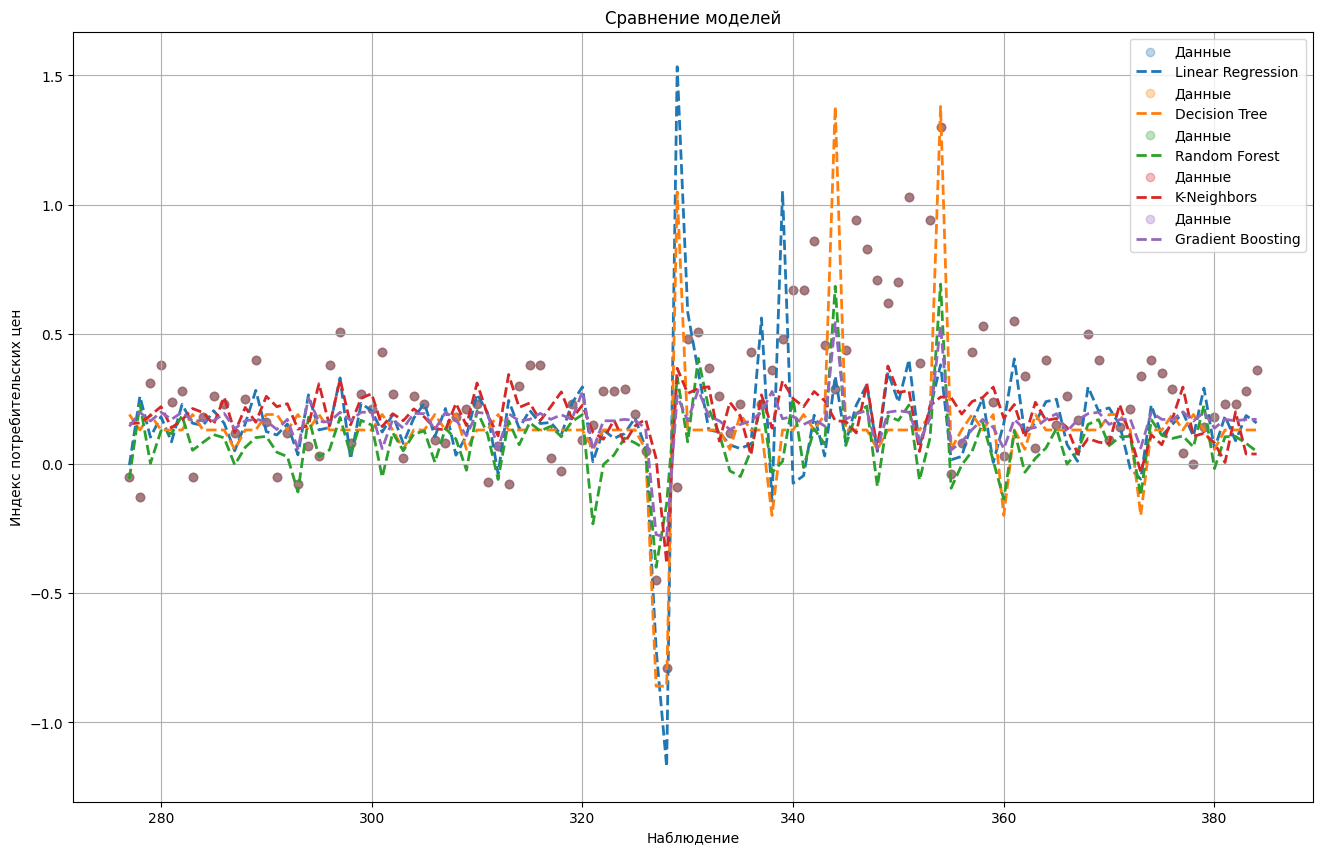

In [131]:
# график сравнения моделей
plt.figure(figsize=(16, 10))

# построение линии предсказаний
for model_name in models.keys():
    model = models[model_name]
    if model_name in params:
        gs = GridSearchCV(model, params[model_name], cv=3, scoring='r2')
        gs.fit(X_train_scaled if model_name == 'K-Neighbors' else X_train, y_train)
        model = gs.best_estimator_
    else:
        model.fit(X_train, y_train)

    if model_name == 'K-Neighbors':
        pred = model.predict(X_test_scaled)
    else:
        pred = model.predict(X_test)

    plt.scatter(X_test['Date'], y_test, alpha=0.3, label='Данные')
    sorted_idx = np.argsort(X_test['Date'])
    plt.plot(X_test['Date'].
iloc[sorted_idx], pred[sorted_idx], '--', linewidth=2, label=model_name)

plt.xlabel('Наблюдение')
plt.ylabel('Индекс потребительских цен')
plt.title('Сравнение моделей')
plt.legend()
plt.grid(True)
plt.show()

In [132]:
# Выбор лучшей модели
best_model_name = results.iloc[0]['Model']
best_model = models[best_model_name]
if best_model_name in params:
    gs = GridSearchCV(best_model, params[best_model_name], cv=3, scoring='r2')
    gs.fit(X_train, y_train)
    best_model = gs.best_estimator_

print(f"\nЛучшая модель: {best_model_name}")
print(f"Параметры: {results.iloc[0]['Params']}")
print(f"R²: {results.iloc[0]['R²']:.3f}, RMSE: {results.iloc[0]['RMSE']:.3f}")


Лучшая модель: Gradient Boosting
Параметры: {'learning_rate': 0.01, 'n_estimators': 100}
R²: 0.076, RMSE: 0.269
